# Data Analytics Track — Task 1: EDA on Retail Sales Data

**Author:** Syed Mohammed Ghouse  
**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

In [2]:
import pandas as pd

## 1. Load Dataset and Initial Inspection

In [3]:
df=pd.read_csv(r'Retail_Sales_Dataset.csv')
df

,Order_ID,Order_Date,Customer_ID,Customer_Age,Gender,Region,Category,Sub_Category,Quantity,Unit_Price,Discount,Sales,Profit
0,ORD-1000,10-11-2024,CUST-309,29.0,Male,West,Office Supplies,Binders,7,225.69,0.00,1579.83,168.51
1,ORD-1001,16-03-2024,CUST-561,35.0,Female,East,Technology,Copiers,2,95.00,0.00,190.00,7.01
2,ORD-1002,01-12-2023,CUST-274,45.0,Male,Central,Office Supplies,Storage,3,194.32,0.30,408.07,44.91
3,ORD-1003,14-01-2022,CUST-455,49.0,Female,Central,Technology,Copiers,2,195.78,0.00,391.56,1.53
4,ORD-1004,04-02-2022,CUST-402,73.0,Female,East,Office Supplies,Art,1,133.10,0.15,113.14,4.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003,ORD-2315,27-03-2024,CUST-593,40.0,Female,Central,Office Supplies,Storage,9,370.27,0.00,3332.43,239.37
2004,ORD-2210,22-10-2022,CUST-329,44.0,Male,West,Office Supplies,Binders,8,215.16,0.20,1377.02,-104.64
2005,ORD-2636,29-01-2024,CUST-202,18.0,Male,East,Technology,Machines,1,221.17,0.20,176.94,-3.55
2006,ORD-1613,02-08-2023,CUST-386,43.0,Female,East,Furniture,Tables,2,139.50,0.20,223.20,15.68


In [8]:
df.shape

(2008, 13)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      2008 non-null   str    
 1   Order_Date    2008 non-null   str    
 2   Customer_ID   2008 non-null   str    
 3   Customer_Age  1983 non-null   float64
 4   Gender        2008 non-null   str    
 5   Region        2008 non-null   str    
 6   Category      2008 non-null   str    
 7   Sub_Category  2008 non-null   str    
 8   Quantity      2008 non-null   int64  
 9   Unit_Price    2008 non-null   float64
 10  Discount      2008 non-null   float64
 11  Sales         2008 non-null   float64
 12  Profit        2008 non-null   float64
dtypes: float64(5), int64(1), str(7)
memory usage: 204.1 KB


In [17]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount,Sales,Profit
count,1983.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000
mean,39.820978,4.998008,248.233292,0.096340,1115.896584,137.459069
std,11.688944,2.605616,142.561973,0.095111,919.613504,214.450730
min,18.000000,1.000000,5.150000,0.000000,5.460000,-385.200000
25%,32.000000,3.000000,124.970000,0.000000,361.357500,3.610000
50%,40.000000,5.000000,246.520000,0.100000,870.355000,62.705000
75%,48.000000,7.000000,369.062500,0.150000,1707.425000,217.450000
max,75.000000,9.000000,499.680000,0.300000,4490.550000,1493.690000


In [15]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Age    25
Gender           0
Region           0
Category         0
Sub_Category     0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Profit           0
dtype: int64

**Observation:** `Customer_Age` has 25 missing values; all other columns are complete.

In [18]:
df.duplicated().sum()

np.int64(8)

**Observation:** 8 duplicate rows found in the dataset.

In [20]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [22]:
df['Month'] = df['Order_Date'].dt.to_period('M')

In [24]:
monthly_sales = df.groupby('Month')['Sales'].sum()

In [28]:
import matplotlib.pyplot as plt

## 2. Time Series Analysis — Monthly Sales Trend

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month'>

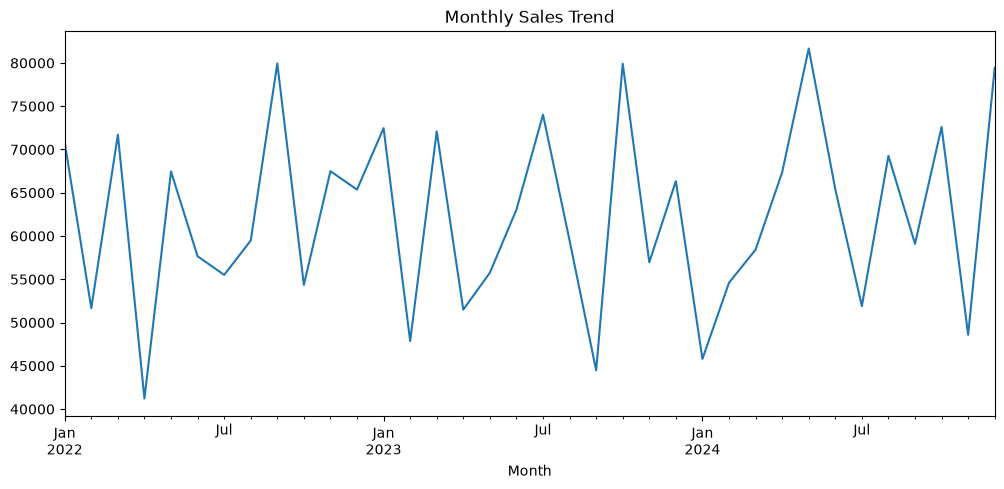

In [31]:
monthly_sales.plot(kind='line', figsize=(12,5), title='Monthly Sales Trend')

**Observation:** Sales fluctuate month to month without one dominant seasonal spike, though certain months are noticeably higher — worth deeper investigation with more business context.

In [33]:
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.00000,-0.06178
Profit,-0.06178,1.00000


In [35]:
df.groupby('Discount')['Profit'].mean()

Discount
0.00    146.414332
0.10    141.755745
0.15    146.373082
0.20    115.018421
0.30     97.059344
Name: Profit, dtype: float64

## 3. Discount vs. Profit Relationship

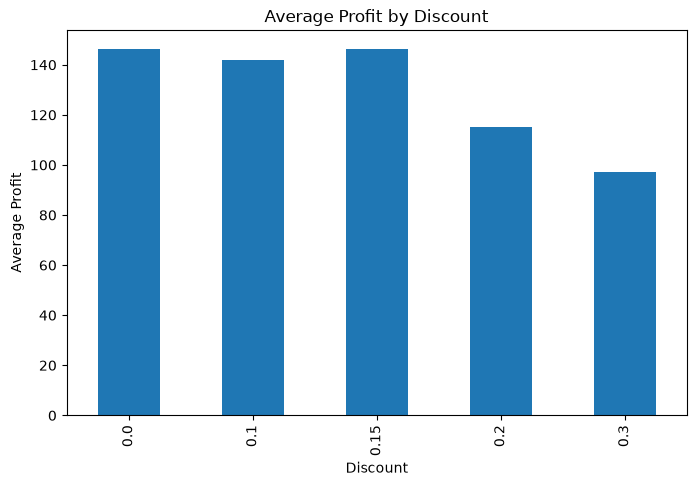

In [37]:
df.groupby('Discount')['Profit'].mean().plot(
    kind='bar',
    title='Average Profit by Discount',
    figsize=(8,5)
)

plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.show()

**Observation:** Discount shows only a weak negative correlation with Profit. Average profit per order declines somewhat as discount increases, but the relationship is not strong — discounting is a minor factor in profitability, not the dominant one.

In [39]:
df['Category'].value_counts()

Category
Office Supplies    866
Technology         630
Furniture          512
Name: count, dtype: int64

In [41]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Office Supplies    939102.70
Technology         727337.27
Furniture          574280.37
Name: Sales, dtype: float64

In [43]:
df.groupby('Category')['Sales'].mean().sort_values(ascending=False)


Category
Technology         1154.503603
Furniture          1121.641348
Office Supplies    1084.414203
Name: Sales, dtype: float64

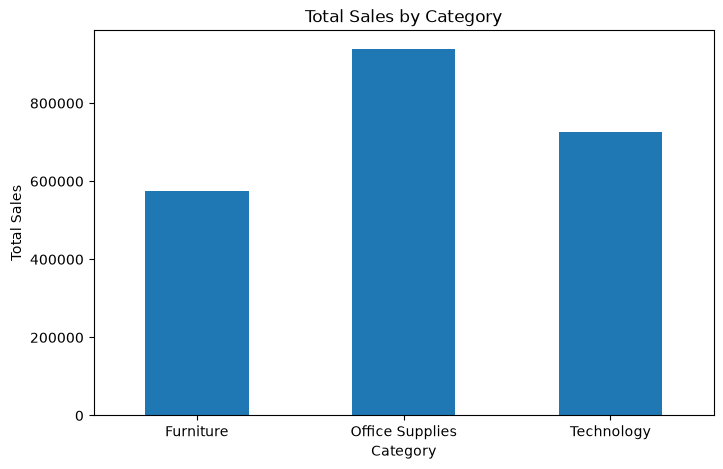

In [47]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(
    kind='bar',
    figsize=(8,5),
    title='Total Sales by Category'
)

plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [49]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

category_profit

Category
Office Supplies    113288.80
Technology          84689.18
Furniture           78039.83
Name: Profit, dtype: float64

In [51]:
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

category_summary['Profit_Margin'] = (
    category_summary['Total_Profit'] /
    category_summary['Total_Sales']
) * 100

category_summary

,Total_Sales,Total_Profit,Profit_Margin
Category,,,
Furniture,574280.37,78039.83,13.589152
Office Supplies,939102.70,113288.80,12.063516
Technology,727337.27,84689.18,11.643729


In [53]:
df[df['Profit'] < 0]['Category'].value_counts()

Category
Office Supplies    195
Technology         148
Furniture           98
Name: count, dtype: int64

In [55]:
loss_rate=df[df['Profit'] < 0].groupby('Category').size() / df.groupby('Category').size() * 100
loss_rate.sort_values(ascending=False)

Category
Technology         23.492063
Office Supplies    22.517321
Furniture          19.140625
dtype: float64

## 4. Product Analysis — Category

In [57]:
df['Year']=df['Order_Date'].dt.year

In [61]:
yealy_category_sales = df.groupby(['Year', 'Category'])['Sales'].sum().unstack()
yealy_category_sales

Category,Furniture,Office Supplies,Technology
Year,,,
2022,214535.97,321696.24,206414.58
2023,170383.11,309890.67,263647.90
2024,189361.29,307515.79,257274.79


**Observation:** Office Supplies leads in order volume and total sales, but Furniture has the highest profit margin — volume leadership does not equal margin leadership. Loss-making order counts and yearly category trends are also shown above for a fuller picture.

In [63]:
df['Region'].value_counts()

Region
East       535
Central    510
West       487
South      476
Name: count, dtype: int64

In [65]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
East       601590.63
West       572438.73
Central    563252.51
South      503438.47
Name: Sales, dtype: float64

In [67]:
df.groupby('Region')['Sales'].mean().sort_values(ascending=False)

Region
West       1175.438871
East       1124.468467
Central    1104.416686
South      1057.643845
Name: Sales, dtype: float64

In [69]:
yearly_region_sales = df.groupby(
    ['Year', 'Region']
)['Sales'].sum().unstack()

yearly_region_sales

Region,Central,East,South,West
Year,,,,
2022,174396.19,217026.56,150048.99,201175.05
2023,195180.46,192041.69,180870.34,175829.19
2024,193675.86,192522.38,172519.14,195434.49


## 5. Regional Analysis

**Observation:** Sales performance and average order value vary meaningfully by region, with distinct yearly patterns shown above.

In [74]:
df['Sub_Category'].value_counts()

Sub_Category
Storage        227
Paper          217
Art            214
Binders        208
Accessories    167
Machines       165
Phones         155
Copiers        143
Sofas          132
Chairs         129
Tables         127
Bookcases      124
Name: count, dtype: int64

In [76]:
df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)

Sub_Category
Storage        258943.69
Art            229772.09
Binders        228111.65
Paper          222275.27
Accessories    201479.68
Machines       189620.10
Copiers        168364.04
Phones         167873.45
Chairs         150313.82
Sofas          147883.11
Tables         140049.14
Bookcases      136034.30
Name: Sales, dtype: float64

In [78]:
df.groupby('Sub_Category')['Sales'].mean().sort_values(ascending=False)

Sub_Category
Accessories    1206.465150
Copiers        1177.370909
Chairs         1165.223411
Machines       1149.212727
Storage        1140.721101
Sofas          1120.326591
Tables         1102.749134
Bookcases      1097.050806
Binders        1096.690625
Phones         1083.054516
Art            1073.701355
Paper          1024.310000
Name: Sales, dtype: float64

In [80]:
subcategory_summary = df.groupby('Sub_Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

subcategory_summary['Profit_Margin'] = (
    subcategory_summary['Total_Profit'] /
    subcategory_summary['Total_Sales']
) * 100

subcategory_summary.sort_values('Profit_Margin', ascending=False)

,Total_Sales,Total_Profit,Profit_Margin
Sub_Category,,,
Chairs,150313.82,25112.93,16.707000
Bookcases,136034.30,19142.59,14.071885
Art,229772.09,31360.16,13.648377
Tables,140049.14,18408.53,13.144336
Machines,189620.10,24522.48,12.932426
Phones,167873.45,21689.01,12.919857
Storage,258943.69,32652.57,12.609911
Binders,228111.65,27973.96,12.263275
Copiers,168364.04,17762.59,10.550109


In [82]:
loss_subcategory = (
    df[df['Profit'] < 0]
    .groupby('Sub_Category')
    .size()
    .sort_values(ascending=False)
)

loss_subcategory

Sub_Category
Paper          58
Binders        49
Accessories    47
Storage        46
Art            42
Machines       39
Copiers        36
Sofas          34
Tables         26
Phones         26
Bookcases      19
Chairs         19
dtype: int64

In [84]:
loss_rate_subcategory = (
    df[df['Profit'] < 0]
    .groupby('Sub_Category')
    .size()
    / df.groupby('Sub_Category').size()
) * 100

loss_rate_subcategory.sort_values(ascending=False)

Sub_Category
Accessories    28.143713
Paper          26.728111
Sofas          25.757576
Copiers        25.174825
Machines       23.636364
Binders        23.557692
Tables         20.472441
Storage        20.264317
Art            19.626168
Phones         16.774194
Bookcases      15.322581
Chairs         14.728682
dtype: float64

In [86]:
subcategory_summary.sort_values(
    ['Profit_Margin', 'Total_Profit'],
    ascending=False
)

,Total_Sales,Total_Profit,Profit_Margin
Sub_Category,,,
Chairs,150313.82,25112.93,16.707000
Bookcases,136034.30,19142.59,14.071885
Art,229772.09,31360.16,13.648377
Tables,140049.14,18408.53,13.144336
Machines,189620.10,24522.48,12.932426
Phones,167873.45,21689.01,12.919857
Storage,258943.69,32652.57,12.609911
Binders,228111.65,27973.96,12.263275
Copiers,168364.04,17762.59,10.550109


## 6. Product Analysis — Sub-Category

**Observation:** Sub-category profit margins vary more than category-level margins, revealing specific strong and weak performers within each category (see loss-rate and margin breakdown above).

In [88]:
df['Customer_ID'].nunique()

578

In [90]:
df['Customer_ID'].value_counts().head(10)

Customer_ID
CUST-42     12
CUST-420    11
CUST-156    10
CUST-170     9
CUST-454     9
CUST-349     9
CUST-221     9
CUST-561     8
CUST-566     8
CUST-550     8
Name: count, dtype: int64

In [92]:
df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False).head(10)

Customer_ID
CUST-420    17576.85
CUST-87     12993.79
CUST-260    12932.99
CUST-221    12733.85
CUST-302    12683.04
CUST-503    12189.79
CUST-550    11988.75
CUST-349    11791.74
CUST-132    11290.29
CUST-202    11216.30
Name: Sales, dtype: float64

In [94]:
customer_summary = df.groupby('Customer_ID').agg(
    Orders=('Customer_ID', 'size'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

customer_summary.sort_values('Total_Sales', ascending=False).head(10)

,Orders,Total_Sales,Total_Profit
Customer_ID,,,
CUST-420,11,17576.85,3332.15
CUST-87,8,12993.79,1491.24
CUST-260,6,12932.99,509.74
CUST-221,9,12733.85,1828.97
CUST-302,7,12683.04,2747.56
CUST-503,7,12189.79,1015.72
CUST-550,8,11988.75,1383.07
CUST-349,9,11791.74,1085.09
CUST-132,6,11290.29,2593.30


In [96]:
df[df['Customer_ID'] == 'CUST-260'][['Sales', 'Discount', 'Profit']]

,Sales,Discount,Profit
209,1093.73,0.10,351.97
365,2934.72,0.00,-87.18
447,3511.51,0.20,127.67
1074,1753.65,0.10,-16.93
1982,127.87,0.15,6.54
2007,3511.51,0.20,127.67


## 7. Customer-Level Analysis

**Observation:** CUST-420 stands out with both the highest sales and highest profit. CUST-260 ranks high in sales but has a notably weak profit margin — investigating their individual orders (above) shows this isn't explained by discounting, since their biggest loss-making order actually had 0% discount. Profit variability here is driven by other factors, not discount rate.

In [98]:
df['Gender'].value_counts()

Gender
Female    1009
Male       999
Name: count, dtype: int64

## 8. Customer Demographics

**Observation:** Customer base is nearly evenly split by gender — no meaningful skew.

In [107]:
bins = [17, 25, 35, 45, 55, 65, 75]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels)
df['Age_Group'].value_counts().sort_index()

Age_Group
18-25    246
26-35    471
36-45    650
46-55    439
56-65    147
66-75     30
Name: count, dtype: int64

In [102]:
df.groupby('Age_Group')['Sales'].mean().sort_index()

Age_Group
18-25    1006.467197
26-35    1076.361635
36-45    1111.610938
46-55    1183.245831
56-65    1217.279864
66-75    1054.972000
Name: Sales, dtype: float64

**Observation:** Average order value rises with age up through the 56–65 group, which has the highest average spend per order despite being a smaller segment than 36–45. This suggests 36–45 drives order volume, while 56–65 drives higher value per order.

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df[['Customer_Age', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit']]
corr_matrix = numeric_cols.corr()
corr_matrix


,Customer_Age,Quantity,Unit_Price,Discount,Sales,Profit
Customer_Age,1.000000,0.030375,0.033364,0.034074,0.049035,0.049787
Quantity,0.030375,1.000000,-0.008505,0.000775,0.605865,0.320402
Unit_Price,0.033364,-0.008505,1.000000,0.018730,0.686155,0.358368
Discount,0.034074,0.000775,0.018730,1.000000,-0.104926,-0.061780
Sales,0.049035,0.605865,0.686155,-0.104926,1.000000,0.521567
Profit,0.049787,0.320402,0.358368,-0.061780,0.521567,1.000000


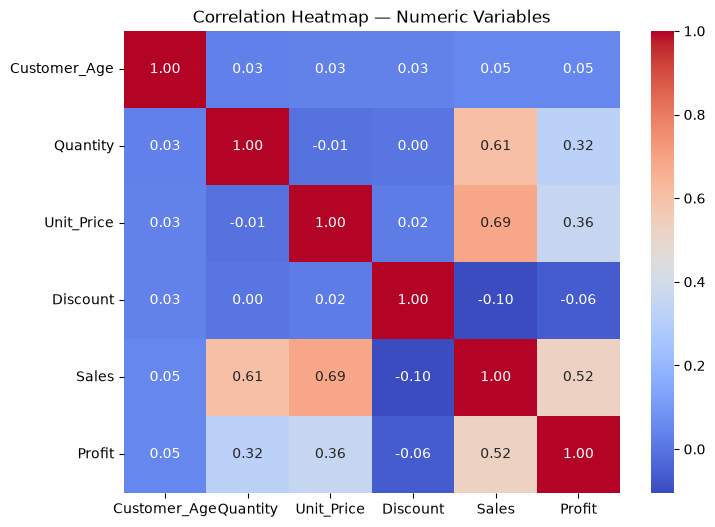

In [108]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Numeric Variables')
plt.show()

## 9. Correlation Heatmap — Numeric Variables

**Observation:** Unit_Price and Quantity correlate most strongly with Sales — expected, since Sales is mathematically derived from both. More informative: Discount has only a weak relationship with Sales and Profit, and Customer_Age shows almost no correlation with anything, confirming age is not a meaningful predictor of spending behaviour in this dataset.

## Key Findings Summary

| Area | Finding |
|---|---|
| Dataset size | 2,008 orders, 13 columns (2022–2024) |
| Top category by volume | Office Supplies (866 orders, ₹939K total sales) |
| Top category by margin | Furniture (13.6% profit margin) |
| Top sub-category by margin | Chairs (16.7% profit margin) |
| Weakest sub-category by margin | Paper (9.6% profit margin) |
| Top region by sales | East (₹601,590 total) |
| Top region by avg. order value | West (₹1,175 per order) |
| Discount → Profit correlation | -0.06 (weak — discounting has minimal effect) |
| Gender split | 50.2% Female, 49.8% Male — balanced |
| Largest age segment | 36–45 years (largest share of customers) |
| Highest avg. spend by age | 56–65 years (₹1,217 per order) |
| Best customer (sales + profit) | CUST-420 (₹17,576.85 sales, ₹3,332.15 profit) |
| High-sales, low-margin customer | CUST-260 (~4% margin — not discount-driven) |
| Strongest Sales correlation | Unit_Price (0.69) |

## 10. Conclusion — Key Insights & Business Recommendations

1. **Prioritize Furniture and Chairs for margin, not just Office Supplies for volume.** Office Supplies drives the most orders and total sales, but Furniture has the best profit margin, and Chairs specifically leads all sub-categories. Consider promotional focus or better inventory allocation toward higher-margin categories rather than just high-volume ones.

2. **Re-evaluate discounting strategy — it's not delivering clear ROI.** Discount shows only a weak negative correlation with both Sales and Profit, meaning current discount levels aren't meaningfully driving additional revenue but are quietly shaving off margin. A/B testing reduced discount tiers could improve profit without much sales loss.

3. **Target the 46–65 age segment for higher-value transactions.** While 36–45 year olds are the largest customer segment by volume, the 56–65 group has the highest average order value. A premium product line or targeted upsell campaign aimed at this demographic could increase revenue per customer.

4. **Investigate high-sales/low-margin customers individually rather than assuming discount is the cause.** Customers like CUST-260 generate strong revenue but weak profit — and in this case, discounting wasn't the driver. Account-level investigation surfaces insights that dataset-wide averages can mask.
